To ensure all the imported libraries are available, you'll need to install them using `pip`.

In [1]:
pip install pandas numpy matplotlib seaborn transformers sentence-transformers

In [3]:
# Import the other required packages and modules.
import pandas as pd
import numpy as np
import datetime
import re
import string
import matplotlib.pyplot as plt
import seaborn
from transformers import pipeline
from sentence_transformers import SentenceTransformer  # Fixed typo here
from sentence_transformers.util import semantic_search

# From the IPython.display package, import display and Markdown
from IPython.display import display, Markdown

In [4]:
# Read the data from runway.csv
runway = pd.read_csv("runway.csv", parse_dates=['review_date'])

# Print the column info
print(runway.info())

print(runway["review_text"][0:10])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      1506 non-null   int64         
 1   item_id      1506 non-null   int64         
 2   rating       1506 non-null   int64         
 3   rented for   1506 non-null   object        
 4   review_text  1506 non-null   object        
 5   category     1506 non-null   object        
 6   height       1503 non-null   object        
 7   size         1506 non-null   int64         
 8   age          1500 non-null   float64       
 9   review_date  1506 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 117.8+ KB
None
0    it hit the floor perfectly with a pair of heel...
1    the dress is absolutely gorgeous unfortunately...
2    even though it was lined with satin this was a...
3    this dress was greatit fit really well and was.

In [5]:
# Remove the forward-slash character
runway['review_text_cleaned'] = runway['review_text'].str.replace(r"\/","")

# Remove punctuation
runway['review_text_cleaned'] = runway['review_text_cleaned'].str.translate(string.punctuation)

# Remove digits
runway['review_text_cleaned'] = runway['review_text_cleaned'].str.replace(r"\d+", "")

# Remove running spaces
runway['review_text_cleaned'] = runway['review_text_cleaned'].str.replace(r"\s{2,}", "")

# Make the text lowercase
runway['review_text_cleaned'] = runway['review_text_cleaned'].str.lower()

# # 2️⃣ Remove punctuation
# runway['review_text_cleaned'] = runway['review_text_cleaned'].str.replace(r'[^\w\s]', '', regex=True)

# # 3️⃣ Remove extra spaces (collapse multiple spaces into one)
# runway['review_text_cleaned'] = runway['review_text_cleaned'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [27]:
from google.colab import userdata
import os

# Set the environment variable in the Colab session
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [28]:
model = "distilbert-base-uncased-finetuned-sst-2-english"

# Instantiate the new pipeline() object for sentiment analysis. Include the model defined above as the model input.
sentimentAnalysis = pipeline("sentiment-analysis", model = model)

#If we dont pass down as a list it will b a series and the pipeline func wont recognize it
# Run sentiment analysis on the cleaned review text.
send_analysis_output = sentimentAnalysis(list(runway['review_text_cleaned']))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [29]:
print(send_analysis_output[0].keys())
print(send_analysis_output)

dict_keys(['label', 'score'])
[{'label': 'POSITIVE', 'score': 0.9998089671134949}, {'label': 'NEGATIVE', 'score': 0.9507226347923279}, {'label': 'NEGATIVE', 'score': 0.9872164130210876}, {'label': 'POSITIVE', 'score': 0.9960770010948181}, {'label': 'NEGATIVE', 'score': 0.9667246341705322}, {'label': 'POSITIVE', 'score': 0.9882996082305908}, {'label': 'POSITIVE', 'score': 0.7901322841644287}, {'label': 'POSITIVE', 'score': 0.9877718687057495}, {'label': 'POSITIVE', 'score': 0.9967693090438843}, {'label': 'POSITIVE', 'score': 0.9960691928863525}, {'label': 'NEGATIVE', 'score': 0.9993739724159241}, {'label': 'NEGATIVE', 'score': 0.7370139956474304}, {'label': 'NEGATIVE', 'score': 0.8242031931877136}, {'label': 'NEGATIVE', 'score': 0.6067982316017151}, {'label': 'POSITIVE', 'score': 0.9996150732040405}, {'label': 'POSITIVE', 'score': 0.995503842830658}, {'label': 'NEGATIVE', 'score': 0.9917631149291992}, {'label': 'POSITIVE', 'score': 0.9996963739395142}, {'label': 'POSITIVE', 'score': 0.9

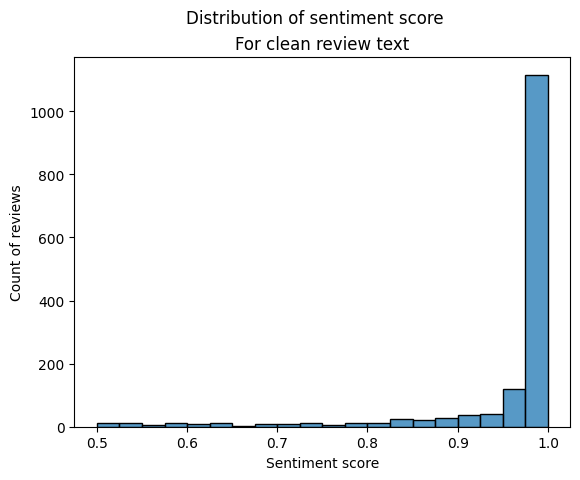

In [30]:
import seaborn as sns

# Parse out the two pieces of output from sent_analysis_output - "label" and "score".
runway['clean_sentiment_category'] = [s['label'] for s in send_analysis_output]
runway['clean_sentiment_score'] = [s['score'] for s in send_analysis_output]

# Create the first histogram using the built-in Pandas histogram method.
sns.histplot(data=runway, x='clean_sentiment_score', bins=20)
plt.suptitle('Distribution of sentiment score')
plt.xlabel("Sentiment score")
plt.ylabel('Count of reviews')
plt.title('For clean review text')
plt.show()

.groupby(['year', 'clean_sentiment_category']) groups the data by year and sentiment category (like Positive, Negative, Neutral).

['user_id'].count() counts the number of reviews for each combination. You could also use any column that’s not null, user_id is used here.

as_index=False ensures the grouped columns stay as columns, not as the index.

Then the columns are renamed for clarity:

'year' → year

'sentiment_category' → sentiment category

'cnt' → count of reviews

Example:

year	sentiment_category	cnt
2018	Positive	120
2018	Negative	30
2019	Positive	140
2019	Negative	25

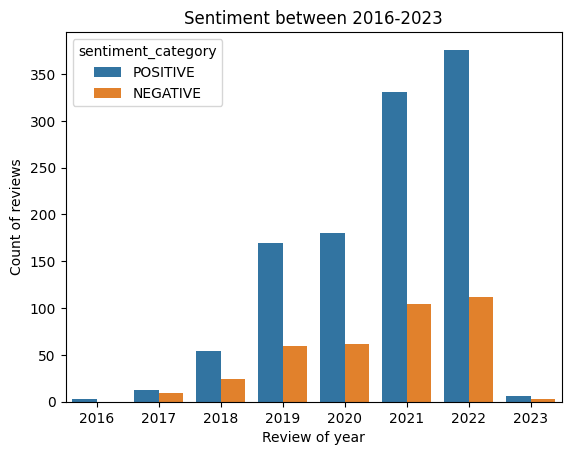

In [31]:
# Create a new column called "year" which is the year of the "review_date".
runway['year'] = runway['review_date'].dt.year
# Create a new dataframe of review counts by "year" and "cleaned_sentiment_category".
chart_data = runway.groupby(['year', 'clean_sentiment_category'], as_index=False )['user_id'].count()
chart_data.columns = ['year', 'sentiment_category', 'cnt']

# Create a bar plot showing the count of reviews for each sentiment category over the years.
sns.barplot(data=chart_data, x='year', y='cnt', hue='sentiment_category', errorbar=None)
plt.title('Sentiment between 2016-2023')
plt.xlabel("Review of year")
plt.ylabel('Count of reviews')
plt.show()


### Task 6: Does Cleaning Text Matter?

Wow - that's quite a set of positive reviews! It seems like the amount of positive reviews increased dramatically in 2021. Potentially a revamp of the customer experience, product quality, more customers, or something else we don't have data for.

From a business context, digging into the common words/n-grams of the positive reviews can be revealing as to what customers love about the products. Doing the same for the negative reviews can be just as informative for what they don't love (i.e. sizing issues, rental service, etc.).

We will look into that soon. But first, let's test the previous comment on preprocessing text. Does it matter for sentiment analysis?

In this task, you will build another sentiment analysis pipeline but, in this case, for the non-cleaned review_text. Then, you will compare the output from the two pipelines to understand if the cleaning made a difference in categorizing sentiment.



In [32]:
# Create a new sentiment analysis output for "review_text".
sent_analysis_2 = sentimentAnalysis(list(runway['review_text']))

# Parse the output into "sentiment_category" and "sentiment_score".
runway['sentiment_category'] = [s['label'] for s in sent_analysis_2]
runway['sentiment_score'] = [s['score'] for s in sent_analysis_2]

# Print the confusion matrix comparing the two sentiment category outputs.
display(pd.crosstab(runway['clean_sentiment_category'], runway['sentiment_category']))

sentiment_category,NEGATIVE,POSITIVE
clean_sentiment_category,,
NEGATIVE,373,1
POSITIVE,2,1130


Based on the previous results, the sentiment of the review was pretty much the same with cleaned text. Good for us! We can use the original text to perform further analysis. Again, this is situation dependent, so be sure to think through the benefits of cleaning vs. leaving the text as is.

Transformers, such as those on Hugging Face, are a component of machine learning / deep learning models which are designed to learn sequential data. Using a concept known as "self-attention", they use other tokens (words) in the sequence (sentence) to build an understanding of a specific token (word).

All of this to say (in a simplified manner) transformers, specifically those trained on VERY large datasets, work well on unstructured, un-cleaned text because it takes the whole sentence into context. And every piece adds to that context see BERT paper here that argues this point
.

This can be particularly powerful from 1) a time-savings perspective and 2) enabling more unstructured text to be leveraged. With less hassle of data preparation, more data can be used to make decisions. Again, make sure you evaluate the use case and determine if the NLP results are meeting performance expectations.

### Task 7: Embeddings

In the next task, we will switch gears to exploring another common use case for Hugging Face and transformers - text embeddings.

Embeddings, in a very simplistic definition, are a vector (numerical) representation of something within n-dimensions. In this case, they are text embeddings. (Note: each transformer model will have a different number of dimensions for its results). Embeddings are useful because they represent human language to computers which enables a more sophisticated execution of similarity, text generation, semantic search, and the like. This can be extremely valuable for business tasks such as recommendations and searching within websites or products.

You will now try this out on the rented for column using the sentence_transformer package
. The model you'll use is the BERT-based "all-MiniLM-L6-v2" model
which transformer that maps sentences and paragraphs to an n-dimensional vector.

Instructions


    - Instantiate a new instance of SentenceTransformer using the specified model (model_id). Save as model.
    - Generate an embedding for each review text using model.encode(). Save as embeddings.
    - Print the shape of the new embeddings array.


In [33]:
model_id = "sentence-transformers/all-MiniLM-L6-v2"

# Instantiate a new SentenceTransformer object.
model = SentenceTransformer(model_id)

# Generate the embeddings for the "rented for" column.
embeddings = model.encode(list(runway['rented for']))

# Print the shape of the new embeddings array.
print(embeddings.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(1506, 384)


### Task 8: Clustering

The all-MiniLM-L6-v2 model outputs embeddings of 384 dimensions. A higher-dimensional embedding can capture more of the relationship between words which is fantastic!

However, for some tasks, such as clustering, it can be a challenge. Clustering tends to perform poorly with higher dimensions of data (i.e. the Curse of Dimensionality), which poses a common challenge in text mining and NLP. Therefore, dimensionality reduction is often employed in order to calculate distance (e.g. Euclidean) between embeddings, then calculate clusters.

Since the transformer is constructed in such a way to be better at learning context, text - words, sentences, documents - that are similar should have similar vectors and therefore be closer together (i.e. in the same cluster).

Understanding which embeddings are closer together can then be used to determine which products, users, reviews, etc. are similar to each other. This is an important step in common method for building recommendations.

Instructions

In this task, you'll conduct dimensionality reduction using the TSNE module from the sklearn package.

    - Import TSNE from sklearn.manifold.
    - Create a new TSNE object using the defined input parameters. Save as tsne.
    - Fit the tsne model with the saved embeddings. Save this as tsne_dims.


In [34]:
# Import TSNE
import sklearn
from sklearn.manifold import TSNE

# Instantiate a new TSNE object.
tsne = TSNE(n_components=2, random_state=42, perplexity=15, init='random', learning_rate=200)

# Generate the tsne dimensions using the saved embeddings.
tsne_dims = tsne.fit_transform(embeddings)

print(tsne_dims.shape)

(1506, 2)


Task 9: Visualizing the Clusters

Now each embedding is 2-dimensional. You don't need to be so drastic in dimensionality reduction for clustering, i.e. use explained variance ratio to determine the right number of components, but is important for visualizing the clusters.

With these smaller vectors, let's move on to generating basic clusters (the average of each category) and building a visualization for them!

# Instructions:

   - Extract the x and y dimensions from the tsne_dims result. Save as new columns in runway named x and y, respectively.
    - Use seaborn.scatterplot to create a new scatterplot using the x and y dimensions and category as the "hue".
    - Set the title as Embeddings visualized for 'rented for' reasons and category using t-SNE.


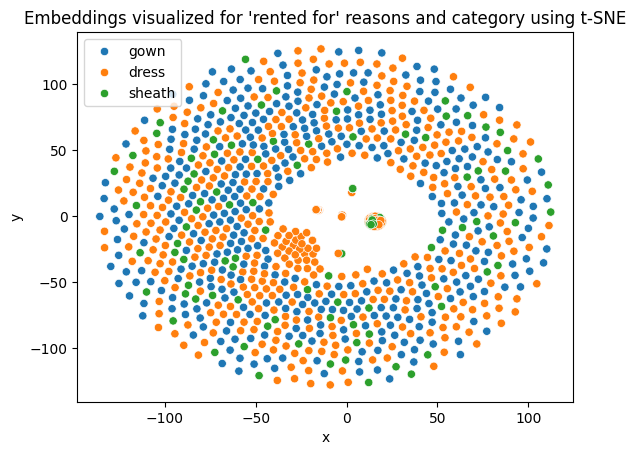

In [35]:
# Parse out the x and y dimensions from the tsne output.
runway['x'] = [x for x,y in tsne_dims]
runway['y'] = [y for x,y in tsne_dims]

# Create the scatterplot
sns.scatterplot(x = "x", y = "y", hue = "category", data = runway)
plt.legend()
plt.title("Embeddings visualized for 'rented for' reasons and category using t-SNE")
plt.show()

In [24]:
# Define query
query = "a gorgeous and flattering dress"

# Embed query
query_emb = model.encode(query, convert_to_tensor=True)

# Calculate similarity between query and item embeddings
hits = semantic_search(query_emb, embeddings, top_k=3)

# Print top similar items
for hit in hits[0]:
    idx = hit['corpus_id']
    print(
        "ITEM ID: ", runway.iloc[idx]['item_id'],
        "; RENTED FOR: ", runway.iloc[idx]['rented for'],
        "; REVIEW", runway.iloc[idx]['review_text'])

ITEM ID:  652189 ; RENTED FOR:  wedding ; REVIEW even though it was lined with satin this was a light beachy dress that was still formal enough for this casual beach weddingitsbackless though so you cant wear a bra and because the neck is such a scoopneck it makes the neckline a little strange if you have a chest and dont wear onei ended up getting one of those stick on bras and the dress looked much betterits much pinker than the model picture which was a pleasant surprisepretty dress comfortable just a little awkward fitting in the chest area if you have anything larger than an abuy the stick on bra
ITEM ID:  1498329 ; RENTED FOR:  wedding ; REVIEW the dress was gorgeous but unfortunately i was unable to wear it due to some quality issues which the renttherunway team was excellent at handlingi would recommend going upsizes from your usual dress size if you have a larger bustit also runs on the long side imand even withinch heels it dragged a little too much for my preferencethe colou

In [25]:
# Instantiate the pipeline for generating text
generator = pipeline(model="gpt2")

# Pre-defined prompt
prompt = "New for this winter season, a lovely dress that"

# Use the prompt as input to the generator to return output.
output = generator(prompt, num_return_sequences=1, return_full_text=False)

# Print the generated text.
print("New Marketing Campaign: ", prompt, output[0]['generated_text'])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


New Marketing Campaign:  New for this winter season, a lovely dress that 's been in the works for more than a year and a half, the new T-shirt from Wintemute is a great way to keep the look fresh and look gorgeous.

The waistline is slim, and the front of the t-shirt is cuffed in two layers to give the garment a bit of extra room. The fit is very flattering, with a lot of room under the bust. The inside is a very stretchy and tight fit, making this a great way to keep everything in place and to give the shirt a little more room to stretch.

The only thing I really like about this shirt is that it's a little light, which makes it a bit of a little different from the original T-shirt.

Wintemute is a very versatile company, but for the most part, they keep the classic T-shirt style. They also do their own t-shirt design, which is a big part of what makes Wintemute unique. I'm really excited to see what they can bring to their upcoming T-shirt.

This dress is available now at:

Wintemute 